In [2]:
!pip install catboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# NOTE: TensorFlow/Keras and Optuna are only needed for the optional deep-learning /
# hyperparameter-tuning sections at the end. Imported there, not here, to keep the
# core pipeline lightweight.

In [4]:
df=pd.read_csv(r"/content/egypt_merged_dataset_new.csv")

In [5]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,...,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Target,Spec_confidence,Spec_source,City
0,NaN,2395000,NaN,KIA,Sportage,2024,Jeep,NaN,Petrol,2.0,...,Automatic,Front,NaN,Left wheel,Dark grey,6,KIA Sportage,HIGH,researched_2026,Tagamo3 - New Cairo
1,NaN,534000,NaN,CHERY,Arrizo 5,2022,Sedan,NaN,Petrol,1.5,...,Automatic,Front,NaN,Left wheel,Bronze,3,CHERY Arrizo 5,HIGH,researched_2026,Nasr city
2,NaN,633000,NaN,FIAT,Tipo,2021,Sedan,NaN,Petrol,1.6,...,Automatic,Front,NaN,Left wheel,Petroleum,4,FIAT Tipo,HIGH,researched_2026,Kafr el-Dawwar
3,NaN,1352000,NaN,HYUNDAI,Tucson Turbo GDI,2021,Jeep,NaN,Petrol,1.6,...,Automatic,Front,NaN,Left wheel,Black,6,HYUNDAI Tucson Turbo GDI,HIGH,researched_2026,Nasr city
4,NaN,1500000,NaN,BMW,X1,2018,Jeep,NaN,Petrol,2.0,...,Automatic,Front,NaN,Left wheel,Gray,6,BMW X1,HIGH,researched_2026,Cairo


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14258 entries, 0 to 14257
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                0 non-null      float64
 1   Price             14258 non-null  int64  
 2   Levy              0 non-null      float64
 3   Manufacturer      14258 non-null  object 
 4   Model             14258 non-null  object 
 5   Prod. year        14258 non-null  int64  
 6   Category          14258 non-null  object 
 7   Leather interior  0 non-null      float64
 8   Fuel type         14258 non-null  object 
 9   Engine volume     14258 non-null  float64
 10  Mileage           14258 non-null  object 
 11  Cylinders         14258 non-null  int64  
 12  Gear box type     14258 non-null  object 
 13  Drive wheels      14258 non-null  object 
 14  Doors             0 non-null      float64
 15  Wheel             14258 non-null  object 
 16  Color             14258 non-null  object

In [7]:
df.isna().sum()

,0
ID,14258
Price,0
Levy,14258
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,14258
Fuel type,0
Engine volume,0


In [8]:
df.duplicated().sum()

np.int64(1229)

In [9]:
df = df.drop_duplicates()


In [10]:
df = df.drop(columns=["ID", "Manufacturer", "Model",'Doors','Wheel', "Color",'Drive wheels','Leather interior','Levy',"Fuel type","Cylinders","Spec_source"])


In [11]:

print(df.shape)
print(df.columns.tolist())

(13029, 10)
['Price', 'Prod. year', 'Category', 'Engine volume', 'Mileage', 'Gear box type', 'Airbags', 'Target', 'Spec_confidence', 'City']


In [12]:
counts = df["Target"].value_counts()

print("عدد الكلاسات:", len(counts))
print("عدد الكلاسات أقل من 50:", (counts < 50).sum())
print("عدد الكلاسات أقل من 100:", (counts < 100).sum())
print("عدد الكلاسات أقل من 200:", (counts < 200).sum())
print("عدد الكلاسات أقل من 500:", (counts < 500).sum())

عدد الكلاسات: 79
عدد الكلاسات أقل من 50: 12
عدد الكلاسات أقل من 100: 29
عدد الكلاسات أقل من 200: 59
عدد الكلاسات أقل من 500: 77


In [13]:
counts = df["Target"].value_counts()

df = df[df["Target"].isin(counts[counts >= 100].index)]

In [14]:
len(df["Target"].value_counts())

50

In [15]:
df.isna().sum()

,0
Price,0
Prod. year,0
Category,0
Engine volume,0
Mileage,0
Gear box type,0
Airbags,0
Target,0
Spec_confidence,0
City,0


In [16]:
df.nunique()

,0
Price,1450
Prod. year,42
Category,4
Engine volume,6
Mileage,786
Gear box type,2
Airbags,7
Target,50
Spec_confidence,3
City,102


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 0 to 13028
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Price            11371 non-null  int64  
 1   Prod. year       11371 non-null  int64  
 2   Category         11371 non-null  object 
 3   Engine volume    11371 non-null  float64
 4   Mileage          11371 non-null  object 
 5   Gear box type    11371 non-null  object 
 6   Airbags          11371 non-null  int64  
 7   Target           11371 non-null  object 
 8   Spec_confidence  11371 non-null  object 
 9   City             11371 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 977.2+ KB


In [18]:
df["Mileage"] = df["Mileage"].str.replace(" km", "", regex=False).astype(int)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 0 to 13028
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Price            11371 non-null  int64  
 1   Prod. year       11371 non-null  int64  
 2   Category         11371 non-null  object 
 3   Engine volume    11371 non-null  float64
 4   Mileage          11371 non-null  int64  
 5   Gear box type    11371 non-null  object 
 6   Airbags          11371 non-null  int64  
 7   Target           11371 non-null  object 
 8   Spec_confidence  11371 non-null  object 
 9   City             11371 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 977.2+ KB


In [20]:
df.nunique()

,0
Price,1450
Prod. year,42
Category,4
Engine volume,6
Mileage,786
Gear box type,2
Airbags,7
Target,50
Spec_confidence,3
City,102


In [21]:
x = df.drop("Target",axis=1)
y = df["Target"]

In [22]:
x = pd.get_dummies(x, columns=["Category", "Spec_confidence", "Gear box type"], drop_first=True)
model_columns = x.columns.tolist()

City_encoder = LabelEncoder()
x["City"] = City_encoder.fit_transform(x["City"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Feature matrix shape:", x.shape)
print("Number of target classes:", len(target_encoder.classes_))

Feature matrix shape: (11371, 12)
Number of target classes: 50


In [23]:
x.head()

,Price,Prod. year,Engine volume,Mileage,Airbags,City,Category_Jeep,Category_Minivan,Category_Sedan,Spec_confidence_LOW,Spec_confidence_MEDIUM,Gear box type_Manual
0,2395000,2024,2.0,300,6,94,True,False,False,False,False,False
1,534000,2022,1.5,86000,3,70,False,False,True,False,False,False
2,633000,2021,1.6,131000,4,52,False,False,True,False,False,False
5,575000,2021,1.5,75000,2,72,False,False,True,False,False,False
6,610000,2021,1.5,25000,3,72,False,False,True,False,False,False


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

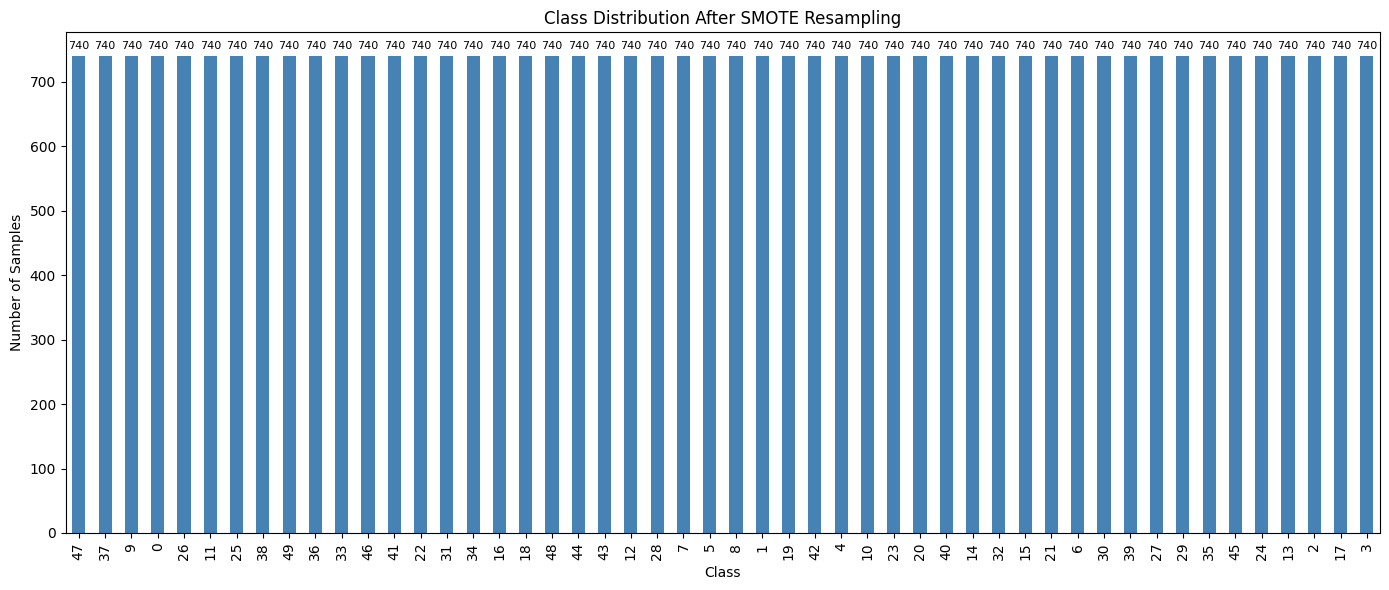

In [25]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(14, 6))
counts = pd.Series(y_train_resampled).value_counts()
ax = counts.plot(kind="bar", color="steelblue")
plt.title("Class Distribution After SMOTE Resampling")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
for i, v in enumerate(counts):
    ax.text(i, v + max(counts) * 0.01, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# FIX: the original notebook plotted this chart using an undefined `y_resampled` variable
# BEFORE calling SMOTE (a leftover from an earlier draft) — it would crash if run top to
# bottom. Now correctly plots `y_train_resampled` after the SMOTE call above.

In [26]:
def count_outliers(frame):
    numerical_cols = frame.select_dtypes(include=["number"]).columns
    for column in numerical_cols:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((frame[column] < lower) | (frame[column] > upper)).sum()
        print(f"{column:<20}: {n_outliers} outliers")

def get_outlier_bounds(frame, column):
    q1, q3 = frame[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def apply_outlier_cap(train_df, test_df, column):
    lower, upper = get_outlier_bounds(train_df, column)
    train_df[column] = train_df[column].clip(lower, upper)
    test_df[column] = test_df[column].clip(lower, upper)

count_outliers(x)

Price               : 669 outliers
Prod. year          : 116 outliers
Engine volume       : 1004 outliers
Mileage             : 171 outliers
Airbags             : 0 outliers
City                : 0 outliers


In [27]:
columns_to_cap = ["Price", "Prod. year", "Engine volume", "Mileage", "Airbags"]

for col in columns_to_cap:
    apply_outlier_cap(X_train_resampled, X_test, col)

In [28]:
print("Training set:")
count_outliers(X_train_resampled)
print()
print("Test set:")
count_outliers(X_test)

Training set:
Price               : 0 outliers
Prod. year          : 0 outliers
Engine volume       : 0 outliers
Mileage             : 0 outliers
Airbags             : 0 outliers
City                : 0 outliers

Test set:
Price               : 140 outliers
Prod. year          : 23 outliers
Engine volume       : 0 outliers
Mileage             : 0 outliers
Airbags             : 0 outliers
City                : 0 outliers


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_resampled.columns, index=X_train_resampled.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [30]:
model_accuracies = {}

In [31]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train_resampled)
y_pred = lr.predict(X_test_scaled)

model_accuracies["Logistic Regression"] = accuracy_score(y_test, y_pred)
print("Accuracy:", model_accuracies["Logistic Regression"])
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.8386813186813187
                            precision    recall  f1-score   support

                    BYD F3       1.00      1.00      1.00        66
            CHERY Arrizo 5       1.00      1.00      1.00        58
             CHERY Tiggo 3       1.00      1.00      1.00        29
             CHERY Tiggo 7       1.00      1.00      1.00        20
            CHEVROLET Aveo       1.00      1.00      1.00        62
           CHEVROLET Cruze       0.39      0.59      0.47        27
           CHEVROLET Lanos       1.00      1.00      1.00        53
           CHEVROLET Optra       0.52      0.70      0.60        93
              DAEWOO Lanos       1.00      1.00      1.00        24
           DAEWOO Nubira 2       1.00      0.97      0.98        29
                 FIAT Tipo       0.73      0.89      0.80        62
           GEELY Emgrand 7       1.00      1.00      1.00        38
            HYUNDAI Accent       1.00      1.00      1.00        24
         HYUNDAI A

In [32]:
modelDT = DecisionTreeClassifier(max_depth=15, min_samples_split=10, random_state=42)
modelDT.fit(X_train_scaled, y_train_resampled)
y_pred = modelDT.predict(X_test_scaled)

model_accuracies["Decision Tree"] = accuracy_score(y_test, y_pred)
print("Accuracy:", model_accuracies["Decision Tree"])
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.9037362637362637
                            precision    recall  f1-score   support

                    BYD F3       1.00      1.00      1.00        66
            CHERY Arrizo 5       0.98      1.00      0.99        58
             CHERY Tiggo 3       1.00      1.00      1.00        29
             CHERY Tiggo 7       1.00      1.00      1.00        20
            CHEVROLET Aveo       1.00      1.00      1.00        62
           CHEVROLET Cruze       0.92      0.41      0.56        27
           CHEVROLET Lanos       1.00      0.96      0.98        53
           CHEVROLET Optra       0.78      0.69      0.73        93
              DAEWOO Lanos       0.92      1.00      0.96        24
           DAEWOO Nubira 2       1.00      1.00      1.00        29
                 FIAT Tipo       0.78      0.94      0.85        62
           GEELY Emgrand 7       1.00      1.00      1.00        38
            HYUNDAI Accent       1.00      1.00      1.00        24
         HYUNDAI A

In [33]:
modelKNN = KNeighborsClassifier(n_neighbors=7, weights="distance")
modelKNN.fit(X_train_scaled, y_train_resampled)
y_pred = modelKNN.predict(X_test_scaled)

model_accuracies["KNN"] = accuracy_score(y_test, y_pred)
print("Accuracy:", model_accuracies["KNN"])
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.8808791208791209
                            precision    recall  f1-score   support

                    BYD F3       0.99      1.00      0.99        66
            CHERY Arrizo 5       1.00      1.00      1.00        58
             CHERY Tiggo 3       1.00      1.00      1.00        29
             CHERY Tiggo 7       1.00      0.95      0.97        20
            CHEVROLET Aveo       1.00      1.00      1.00        62
           CHEVROLET Cruze       0.85      0.81      0.83        27
           CHEVROLET Lanos       0.98      0.89      0.93        53
           CHEVROLET Optra       0.58      0.76      0.66        93
              DAEWOO Lanos       0.82      0.96      0.88        24
           DAEWOO Nubira 2       1.00      0.97      0.98        29
                 FIAT Tipo       0.78      0.87      0.82        62
           GEELY Emgrand 7       0.97      1.00      0.99        38
            HYUNDAI Accent       0.96      0.96      0.96        24
         HYUNDAI A

In [34]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_resampled)

modelXGBC = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    objective="multi:softmax", random_state=42
)
modelXGBC.fit(X_train_scaled, y_train_resampled, sample_weight=sample_weights)
pred = modelXGBC.predict(X_test_scaled)

model_accuracies["XGBoost"] = accuracy_score(y_test, pred)
print("Accuracy:", model_accuracies["XGBoost"])
print(classification_report(y_test, pred, target_names=target_encoder.classes_))

Accuracy: 0.96
                            precision    recall  f1-score   support

                    BYD F3       1.00      1.00      1.00        66
            CHERY Arrizo 5       0.98      1.00      0.99        58
             CHERY Tiggo 3       1.00      1.00      1.00        29
             CHERY Tiggo 7       1.00      1.00      1.00        20
            CHEVROLET Aveo       1.00      1.00      1.00        62
           CHEVROLET Cruze       0.96      0.85      0.90        27
           CHEVROLET Lanos       1.00      0.98      0.99        53
           CHEVROLET Optra       0.92      0.91      0.92        93
              DAEWOO Lanos       0.96      1.00      0.98        24
           DAEWOO Nubira 2       1.00      1.00      1.00        29
                 FIAT Tipo       0.89      0.94      0.91        62
           GEELY Emgrand 7       1.00      1.00      1.00        38
            HYUNDAI Accent       1.00      1.00      1.00        24
         HYUNDAI Accent RB      

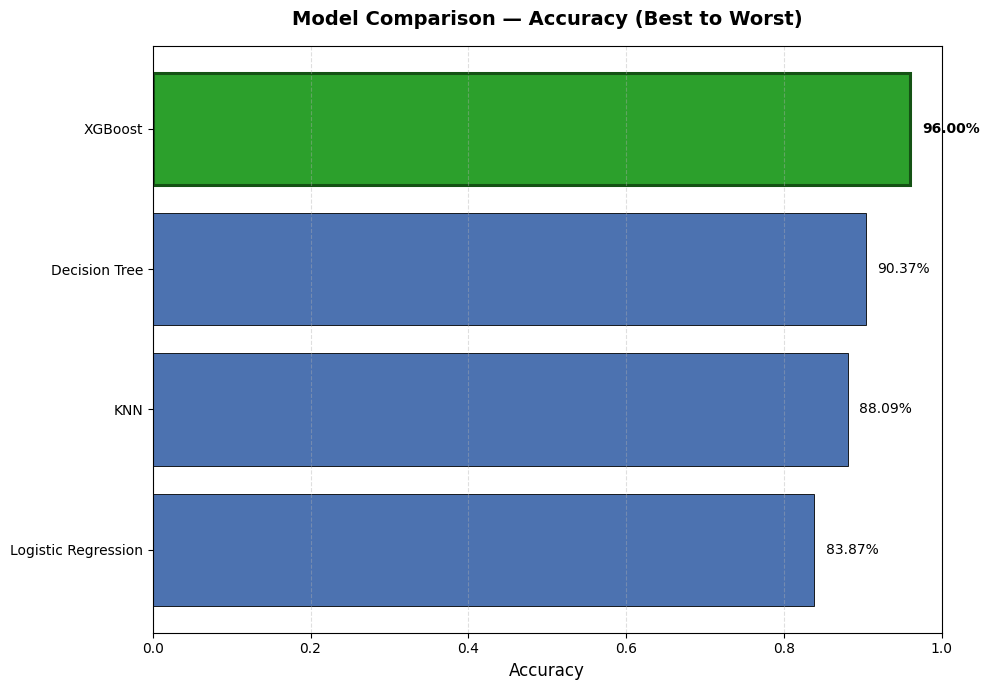

Best model: XGBoost (96.00%)


In [36]:
results_df = pd.Series(model_accuracies).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ["#2ca02c" if i == 0 else "#4C72B0" for i in range(len(results_df))]
bars = plt.barh(results_df.index, results_df.values, color=colors, edgecolor="black", linewidth=0.6)
bars[0].set_linewidth(2.2)
bars[0].set_edgecolor("#145214")

plt.xlabel("Accuracy", fontsize=12)
plt.title("Model Comparison — Accuracy (Best to Worst)", fontsize=14, fontweight="bold", pad=15)
plt.gca().invert_yaxis()
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.4)
for i, v in enumerate(results_df):
    plt.text(v + 0.015, i, f"{v:.2%}", va="center", fontsize=10, fontweight="bold" if i == 0 else "normal")
plt.tight_layout()
plt.show()

print("Best model:", results_df.index[0], f"({results_df.iloc[0]:.2%})")

In [35]:
sample = pd.DataFrame([{
        "Price": 6000,
        "Levy": 400,
        "Prod. year": 2018,
        "Category": "Hatchback",
        "Fuel type": "Hybrid",
        "Engine volume": 2.5,
        "Mileage": 170000,
        "Cylinders": 4,
        "Gear box type": "Variator",
        "Airbags": 6
}])

sample_encoded = pd.get_dummies(sample, columns=["Category", "Fuel type", "Gear box type"], drop_first=True)
sample_encoded = sample_encoded.reindex(columns=model_columns, fill_value=0)
sample_scaled = scaler.transform(sample_encoded)

pred_encoded = modelXGBC.predict(sample_scaled)[0]
pred_label = target_encoder.inverse_transform([pred_encoded])[0]
print("Predicted Target:", pred_label)

proba = modelXGBC.predict_proba(sample_scaled)[0]
top3_idx = np.argsort(proba)[-3:][::-1]
print("\nTop 3 probabilities:")
for idx in top3_idx:
    print(f"  {target_encoder.classes_[idx]}: {proba[idx]*100:.1f}%")

Predicted Target: OPEL Vectra

Top 3 probabilities:
  OPEL Vectra: 91.1%
  VOLKSWAGEN Passat: 3.8%
  NISSAN Sentra: 2.4%
